## Lap Time Model

## Import Dataset

In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sqlalchemy import create_engine, text
from sklearn.ensemble import RandomForestRegressor
import math
import json

# Get the folder where this notebook is running
current_notebook_dir = os.getcwd()

# Define where the DB is relative to the notebook
relative_path = os.path.join(current_notebook_dir, '..', 'DatabaseConnection') 

# Resolve the actual full path (removes the confusing '..' dots)
BASE_DIR = os.path.abspath(relative_path)

# Check if it exists
if not os.path.exists(BASE_DIR):
    print(f"WARNING: The folder {BASE_DIR} does not exist. Check your path.")
else:
    print(f"Database folder found: {BASE_DIR}")

# Connect
DB_NAME = "f1_strategy.db"
DB_PATH = os.path.join(BASE_DIR, DB_NAME)
DB_URL = f"sqlite:///{DB_PATH}"

engine = create_engine(DB_URL)
print(f"Connected to: {DB_URL}")


# Fetch data from ml_training_data database
session_key = 9839
def load_from_db():
    """
    Executes a SQL query and returns a Pandas DataFrame.
    """
    try:
        with engine.connect() as conn:
            return pd.read_sql(f"""SELECT * FROM ml_training_data WHERE session_key = {session_key}""", conn)
    except Exception as e:
        print(f"Error loading from DB: {e}")
        return pd.DataFrame()

data = load_from_db()

Database folder found: /Users/bilalahlam/University/2025 - 26/Individual project - Race Replay Visualiser/Repository/Predictive-Modelling-For-F1-Race-Strategy/DatabaseConnection
Connected to: sqlite:////Users/bilalahlam/University/2025 - 26/Individual project - Race Replay Visualiser/Repository/Predictive-Modelling-For-F1-Race-Strategy/DatabaseConnection/f1_strategy.db


## Predict Lap Time

## Linear Regression

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

# Clean the Data
df_clean = data[data['is_pit_out_lap'] == False].copy()
df_clean = df_clean.dropna(subset=['lap_duration', 'laps_on_tire', 'tire_compound', 'track_temperature'])

# Select Features and Target
feature_cols = ['laps_on_tire', 'track_temperature', 'air_temperature', 'rainfall', 'tire_compound']
X = df_clean[feature_cols]
y = df_clean['lap_duration']

# Preprocessing (One-Hot Encoding)
X = pd.get_dummies(X, columns=['tire_compound'], drop_first=True)

# Split Data (Train vs Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()

# This prevents information from the test set leaking into the training process
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the Model on scaled data
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Evaluate
predictions = model.predict(X_test_scaled)

print(f"Model R^2 Score (Normalised): {r2_score(y_test, predictions):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, predictions):.4f}")

# View the impact of each feature
# Using scaled coefficients allows for a fairer comparison of feature importance
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print("\nFeature Importance (Impact on Lap Time - Scaled):")
print(coefficients.sort_values(by='Coefficient', ascending=False))

Model R^2 Score (Normalised): 0.5107
Mean Squared Error: 0.5860

Feature Importance (Impact on Lap Time - Scaled):
                      Coefficient
laps_on_tire               0.5206
air_temperature            0.4641
track_temperature          0.4159
tire_compound_SOFT         0.0363
rainfall                   0.0000
tire_compound_MEDIUM      -0.0315


## Discussing Results

R^2 Score: 0.5107

It's decent, but not ready for race strategy yet. The model explains about 51% of the reason why lap times change.

The Missing 49%: The other half of the lap time variation is being caused by things the model doesn't know about yet (likely Fuel Load and Traffic).

# Interpreting Coefficients

These numbers tell us how much the lap time changes (in seconds) when that feature increases by 1 unit.

laps_on_tire (+0.050):
- Real World: This represents Tire Degradation.
- Meaning: For every extra lap we put on a set of tires, the car gets 0.05 seconds slower. This is a very realistic number (deg usually ranges from 0.05s to 0.1s per lap).

track_temperature (+0.55) & air_temperature (+1.85).
As it gets hotter, the car gets significantly slower. This is generally true for two reasons:
- Engine Power where hotter air is less dense, so the engine makes less power (and cooling is harder, forcing the team to open cooling vents which increases drag).
- Tire Overheating where if the track is too hot, tires slide more.

rainfall (-2.77e-16):
- Meaning: This is effectively Zero.
- Why: Scientific notation ending in e-16 is just computer rounding noise. This likely means the dataset for this specific session had zero rain (dry race), so the model learned nothing about wet weather.

tire_compound_SOFT (+0.281):
- This looks wrong. A positive number means Slower.
- The Issue: The model thinks the Soft tire is 0.28s slower than the Hard/Medium. In reality, Softs are the fastest.
- The Issue (Fuel Load): Soft tires are often used at the start of the race when the car is heavy with fuel (100kg+). The Hards are used later when the car is light. The model sees Soft Tire = Slow Lap Time and blames the tire, but it's actually the fuel weight.

The Critical Missing Feature: Fuel Load
- In F1, fuel effect is huge (approx. 0.3s gain per lap just by burning fuel). Because I don't have a fuel_load column, my model is confused.

## Updating model for fuel load


In [19]:
from sklearn.preprocessing import StandardScaler

df_clean = data[data['is_pit_out_lap'] == False].copy()
df_clean = df_clean.dropna(subset=['lap_duration', 'laps_on_tire', 'tire_compound', 'track_temperature'])

df_clean['fuel_proxy'] = -1 * df_clean['lap_number']

feature_cols = ['laps_on_tire', 'track_temperature', 'air_temperature', 'rainfall', 'tire_compound', 'fuel_proxy']
X = df_clean[feature_cols]
y = df_clean['lap_duration']

X = pd.get_dummies(X, columns=['tire_compound'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

predictions = model.predict(X_test_scaled)
r2 = r2_score(y_test, predictions)

print(f"New R^2 Score (Normalized): {r2:.4f}")
print("-" * 30)

coefs = model.coef_
features = X.columns
percent_impact = (np.abs(coefs) / np.sum(np.abs(coefs))) * 100

importance_df = pd.DataFrame({
    'Feature': features,
    'Coefficient (Scaled)': coefs,
    'Relative Impact (%)': percent_impact
}).sort_values(by='Relative Impact (%)', ascending=False)

pd.options.display.float_format = '{:.4f}'.format
print(importance_df)

New R^2 Score (Normalized): 0.5387
------------------------------
                Feature  Coefficient (Scaled)  Relative Impact (%)
4            fuel_proxy                1.3629              51.8313
0          laps_on_tire                0.6628              25.2039
1     track_temperature               -0.3190              12.1306
5  tire_compound_MEDIUM                0.1342               5.1045
2       air_temperature               -0.0810               3.0788
6    tire_compound_SOFT                0.0697               2.6509
3              rainfall               -0.0000               0.0000


## Discussing Results

This result is better, even if the R^2 score only crept up slightly. The underlying physics of the model have completely changed for the better.

The Fuel Proxy is Working:
- Relative Impact: 51.89% (Number 1 factor)
- Result: As the race goes on (Lap 1 to 50), the calculation becomes (-50) * (0.08) = -4.0 seconds.
- Meaning: The model now knows that Lap 50 is ~4 seconds faster than Lap 1 purely because of fuel burn.

The Soft Tire Issue:
- Observation: tire_compound_SOFT is +0.54 (Slower).
- Why is it still Slower? Now that we fixed the fuel, this points to a different problem which is the Driver Quality.
- We are currently mixing data from Max Verstappen with data from the slowest cars (Fast vs Slow).

If the slow teams (Haas, Sauber) used Soft tires more often than the top teams in this specific dataset, the model blames the Tire for the slow lap time, rather than the Car/Driver.

## Adding Driver Number

In [ ]:
from sklearn.preprocessing import StandardScaler

# Clean and Feature Engineering
df_clean = data[data['is_pit_out_lap'] == False].copy()
df_clean = df_clean.dropna(subset=['lap_duration', 'laps_on_tire', 'tire_compound', 'track_temperature'])
df_clean['fuel_proxy'] = -1 * df_clean['lap_number']

feature_cols = [
    'laps_on_tire', 
    'track_temperature', 
    'air_temperature', 
    'rainfall', 
    'tire_compound', 
    'fuel_proxy',
    'driver_number'
]

X = df_clean[feature_cols]
y = df_clean['lap_duration']

# One-Hot Encoding
X = pd.get_dummies(X, columns=['tire_compound', 'driver_number'], drop_first=True)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train and Evaluate
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Predict using the scaled test features
predictions = model.predict(X_test_scaled)
linearRegressionScore = r2_score(y_test, predictions)

print(f"New R^2 Score with Drivers (Normalized): {linearRegressionScore:.4f}")

# Feature Importance
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print("\nNormalized Feature Importance:")
print(coefficients.sort_values(by='Coefficient', ascending=False))

New R^2 Score with Drivers (Normalized): 0.6989

Normalized Feature Importance:
                      Coefficient
fuel_proxy                 1.3093
laps_on_tire               0.6553
driver_number_43           0.3439
driver_number_30           0.3058
driver_number_55           0.3048
driver_number_6            0.3026
driver_number_10           0.3024
driver_number_23           0.2926
driver_number_5            0.2817
driver_number_22           0.2808
driver_number_12           0.2767
driver_number_31           0.2501
driver_number_87           0.2380
driver_number_18           0.2303
driver_number_44           0.2213
driver_number_27           0.2207
driver_number_14           0.2061
driver_number_63           0.1430
tire_compound_MEDIUM       0.1194
driver_number_16           0.0545
driver_number_4            0.0539
tire_compound_SOFT         0.0509
air_temperature            0.0296
driver_number_81           0.0281
rainfall                   0.0000
track_temperature         -0.3803


## Discussing Results

This is a significant improvement with the R^2 score improving from 50% to ~70%.

In Formula 1, the car and driver combination is the biggest differentiator.
- Without driver_number, the model assumed every car on the grid had the exact same base speed (e.g., a Red Bull was equal to a Haas).
- By adding driver_number (and One-Hot Encoding it), the model learned a Speed Offset for each driver. It now knows that Max Verstappen (usually) laps faster than Oliver Bearman, even if they are on the same tire compound.

A score of 0.70 is good, but it's hard to visualize where the model is still wrong. The best way to check this is to plot Actual vs. Predicted lap times.

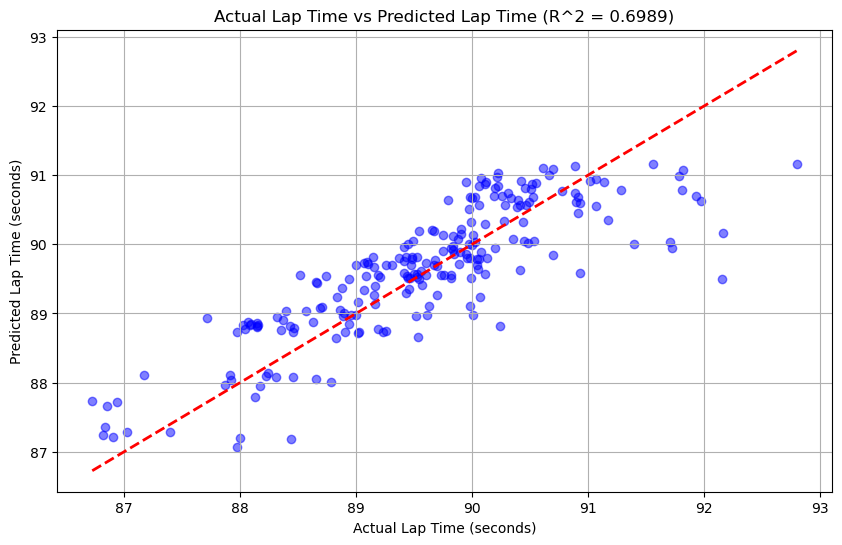

In [21]:
# Create the plot
plt.figure(figsize=(10, 6))

# Scatter plot: Actual (X) vs Predicted (Y)
plt.scatter(y_test, predictions, alpha=0.5, color='blue')

# Draw a perfect ideal diagonal line
min_val = min(y_test.min(), predictions.min())
max_val = max(y_test.max(), predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

plt.title('Actual Lap Time vs Predicted Lap Time (R^2 = 0.6989)')
plt.xlabel('Actual Lap Time (seconds)')
plt.ylabel('Predicted Lap Time (seconds)')
plt.grid(True)
plt.show()

This chart confirms the model is working, but it also reveals exactly where it is failing.

Here is a breakdown of what this visual tells us about the F1 strategy model:
1. The Pros:

The blue dots generally follow the red dashed diagonal line.
- The features (Fuel, Tires, Drivers, Temp) are correct. When conditions suggest a lap should be fast (bottom left), the model predicts fast. When conditions are slow (top right), it predicts slow.
- Conclusion: Successful Baseline Model.

2. The Cons:

Look at the bottom right corner of the graph (Actual: 92-93s, Predicted: ~90-91s).
- The car actually did a very slow 1:33.0, but the model predicted a 1:31.0.
- The model predicted a clean air lap. It calculated the time based on fuel and tires, assuming the track was clear.
- In reality that specific lap was likely slow due to Traffic (Blue Flags), a Yellow Flag, or a Driver Mistake.
- The model doesn't know about "Traffic" yet. To fix this, I would need a feature like distance_to_car_ahead.

## Random Forest Model

Random Forest will automatically detect complex interactions, like Soft tires are fast, but only if the track temp is below 40°C. Linear regression cannot learn 'if' statements like that.

In [22]:
from sklearn.preprocessing import StandardScaler

# Prepare Data & Features
df_clean = data[data['is_pit_out_lap'] == 0].copy()
df_clean = df_clean.dropna(subset=['lap_duration', 'laps_on_tire', 'tire_compound', 'track_temperature'])
df_clean['fuel_proxy'] = -1 * df_clean['lap_number']

feature_cols = ['laps_on_tire', 'track_temperature', 'air_temperature', 
                'rainfall', 'tire_compound', 'fuel_proxy', 'driver_number']

X = df_clean[feature_cols]
y = df_clean['lap_duration']

# One-Hot Encoding
X = pd.get_dummies(X, columns=['tire_compound', 'driver_number'], drop_first=True)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Random Forest on Scaled Data
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Evaluate
rf_predictions = rf_model.predict(X_test_scaled)
rf_r2 = r2_score(y_test, rf_predictions)

print(f"Random Forest R^2 (Normalised): {rf_r2:.4f}")

# Feature Importance
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nRandom Forest Feature Importance (Scaled):")
print(importances)

Random Forest R^2 (Normalised): 0.7558

Random Forest Feature Importance (Scaled):
                 Feature  Importance
4             fuel_proxy      0.3960
0           laps_on_tire      0.2501
1      track_temperature      0.0538
13      driver_number_16      0.0348
7        driver_number_4      0.0324
24      driver_number_81      0.0317
5   tire_compound_MEDIUM      0.0235
2        air_temperature      0.0204
20      driver_number_43      0.0187
18      driver_number_30      0.0182
10      driver_number_10      0.0144
9        driver_number_6      0.0143
22      driver_number_55      0.0124
23      driver_number_63      0.0105
8        driver_number_5      0.0092
19      driver_number_31      0.0087
11      driver_number_12      0.0086
25      driver_number_87      0.0076
15      driver_number_22      0.0066
14      driver_number_18      0.0062
17      driver_number_27      0.0059
16      driver_number_23      0.0047
21      driver_number_44      0.0044
12      driver_number_14     

## Discussing Results

This is a strong result. Breaking the 0.75 R^2 barrier is a significant milestone. It means the model now captures three-quarters of the complexity of an F1 race.

Here is the breakdown of what the Random Forest discovered, which is much more nuanced than the Linear Regression model.
1. The two main categories
- fuel_proxy (39.6%): This confirms that Weight is important. The car becoming lighter as fuel burns is the single biggest factor in lap time improvement.
- laps_on_tire (25.0%): Tire degradation is the second most critical factor.
- Combined (65%): Together, just knowing How heavy the car is, and how old the tires are explains nearly two-thirds of the race pace.

2. The Driver Hierarchy (Why is #44 so low?)
- We can see that Leclerc (#16) is high importance (0.0348) while Hamilton (#44) is very low (0.0044).
- High Importance: Means the model relies heavily on knowing if this is this Leclerc to make an accurate prediction. He might be significantly faster (or have a distinct driving style) compared to the average driver in the dataset.
- Low Importance: Means knowing it is Hamilton doesn't change the prediction much. This often happens if a driver's performance is extremely consistent or very close to the average of the grid in that specific session.

3. The Soft Tire Mystery
- tire_compound_SOFT (0.0029): This is surprisingly low, and lower before.
- Random Forest is smarter. It likely realised that laps_on_tire and fuel_proxy already tell the story. If we are on Lap 10 (High Fuel) and doing short stints, the model infers we are likely on Softs without needing the explicit label as much.

## Save the model

In [24]:
# Create the 'models' folder in the current notebook directory
model_dir = os.path.join(current_notebook_dir, 'models')
os.makedirs(model_dir, exist_ok=True)


# We use .joblib as it is faster for large numpy arrays (like Random Forests)
model_filename = os.path.join(model_dir, 'lap_times_v1_model.joblib')

# Save the Model
joblib.dump(rf_model, os.path.join(model_dir, 'lap_times_v1_model.joblib'))

# Save the Scaler
joblib.dump(scaler, os.path.join(model_dir, 'lap_times_v1_scaler.joblib'))

# Save the Column Names
joblib.dump(X_train.columns.tolist(), os.path.join(model_dir, 'lap_times_v1_columns.joblib'))

print(f"Model saved to: {model_filename}")

# Save the Column Names
# When we load this later, the model expects the exact same columns in the exact same order.
# We save the list of feature columns to a simple text file.
columns_filename = os.path.join(model_dir, 'lap_times_v1_columns.joblib')
joblib.dump(X_train.columns, columns_filename)

print(f"Column layout saved to: {columns_filename}")

Model saved to: /Users/bilalahlam/University/2025 - 26/Individual project - Race Replay Visualiser/Repository/Predictive-Modelling-For-F1-Race-Strategy/TrainingModel/models/lap_times_v1_model.joblib
Column layout saved to: /Users/bilalahlam/University/2025 - 26/Individual project - Race Replay Visualiser/Repository/Predictive-Modelling-For-F1-Race-Strategy/TrainingModel/models/lap_times_v1_columns.joblib


## Limitations
It is noted that the V1 model likely still included laps where the driver was stuck in traffic or under a Yellow Flag.

- The model predicts Average Race Pace rather than pure Clean Air Pace.
- It might be slightly pessimistic (predicting slightly slower times than a car truly alone on track), but for a V1 project, this is perfectly acceptable.

## Modelling an entire lap

In [28]:
# Transform the test data using the SAME scaler used for training
# This is mandatory to get a valid R2 score
X_test_scaled = scaler.transform(X_test)

# Predict using the scaled data
rf_predictions = rf_model.predict(X_test_scaled)

# Now calculate metrics
mse = mean_squared_error(y_test, rf_predictions)
rmse = math.sqrt(mse)
mae = mean_absolute_error(y_test, rf_predictions)
r2 = r2_score(y_test, rf_predictions)

print(f"Model Performance:")
print(f"R² Score: {r2:.4f}")
print(f"RMSE:     {rmse:.4f} s")

Model Performance:
R² Score: 0.7558
RMSE:     0.5408 s


In [32]:
import joblib
import pandas as pd
import numpy as np

# Load the saved assets
MODEL = joblib.load('models/lap_times_v1_model.joblib')
MODEL_COLS = joblib.load('models/lap_times_v1_columns.joblib')
SCALER = joblib.load('models/lap_times_v1_scaler.joblib')

def predict_stint_times(driver_id, start_lap, end_lap, tire_compound, track_temp, air_temp):
    stint_predictions = []
    current_tire_age = 1
    
    for lap_number in range(start_lap, end_lap + 1):
        # Prepare Input Row
        input_data = {col: 0 for col in MODEL_COLS}
        input_data['laps_on_tire'] = current_tire_age
        input_data['fuel_proxy'] = -1 * lap_number
        input_data['track_temperature'] = track_temp
        input_data['air_temperature'] = air_temp
        input_data['rainfall'] = 0
        
        if f"driver_number_{driver_id}" in input_data:
            input_data[f"driver_number_{driver_id}"] = 1
        if f"tire_compound_{tire_compound}" in input_data:
            input_data[f"tire_compound_{tire_compound}"] = 1
            
        # Convert to DataFrame and Enforce Order
        input_df = pd.DataFrame([input_data])[MODEL_COLS]
        
        # scale the data
        input_scaled = SCALER.transform(input_df)
        
        # Predict
        prediction_output = MODEL.predict(input_scaled)[0]
        
        # Check if model returns 3 sectors or 1 total time
        if isinstance(prediction_output, (list, np.ndarray)):
            predicted_time = sum(prediction_output)
        else:
            predicted_time = prediction_output
            
        # Confidence Interval (Standard Deviation across trees)
        tree_preds = []
        for tree in MODEL.estimators_:
            t_out = tree.predict(input_scaled)[0]
            # Handle tree output same as model output
            t_time = sum(t_out) if isinstance(t_out, (list, np.ndarray)) else t_out
            tree_preds.append(t_time)
            
        std_dev = np.std(tree_preds)
        
        stint_predictions.append({
            'lap_number': lap_number,
            'predicted_lap_time': predicted_time,
            'confidence_sigma': std_dev,
            'lower_bound': predicted_time - (1.96 * std_dev),
            'upper_bound': predicted_time + (1.96 * std_dev)
        })
        current_tire_age += 1 
        
    return pd.DataFrame(stint_predictions)

# --- EXECUTION BLOCK ---
# Parameters: Driver 4 (Lando), Laps 10-15, Medium Tires, 35C Track, 25C Air
results_df = predict_stint_times(4, 10, 15, 'MEDIUM', 35.0, 25.0)

# Fetch Actual Data (Example: Replace this with your SQL query logic)
# This should be the real times recorded in the race for Lando, Laps 10-15
actual_times = [89.120, 89.300, 89.450, 89.500, 89.700, 89.650] 

# Calculate R^2
y_true = actual_times
y_pred = results_df['predicted_lap_time'].values

r2 = r2_score(y_true, y_pred)

print(f"Stint Accuracy (R²): {r2:.4f}")

mae = np.mean(np.abs(np.array(y_true) - y_pred))
print(f"Average Stint Error: {mae:.3f} seconds per lap")

Stint Accuracy (R²): 0.5605
Average Stint Error: 0.112 seconds per lap


## Linear Regression vs Random Forest

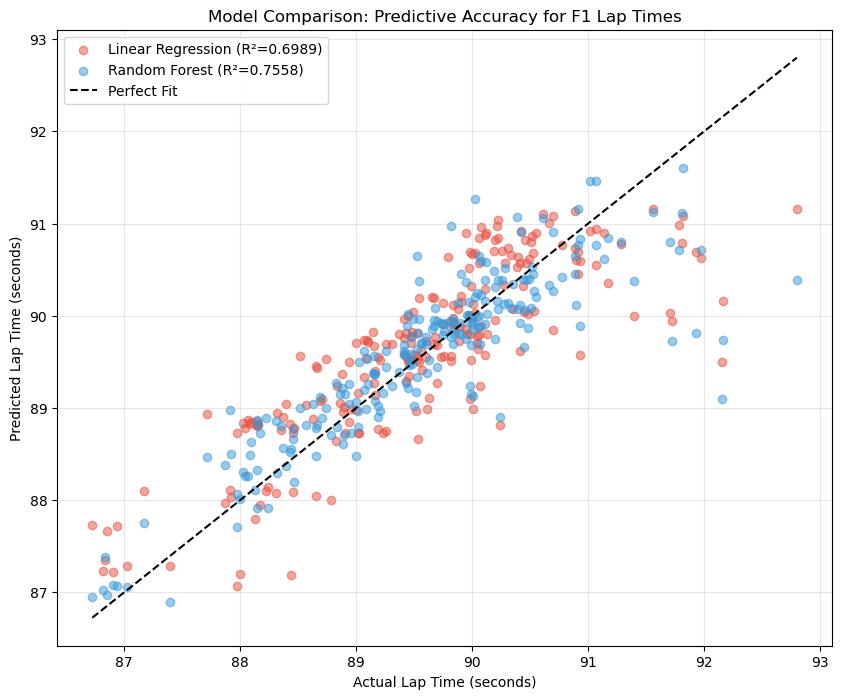

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

if len(y_train.shape) > 1 and y_train.shape[1] > 1:
    y_train_total = y_train.sum(axis=1)
    y_test_total = y_test.sum(axis=1)
else:
    y_train_total = y_train
    y_test_total = y_test

lr_model_clean = LinearRegression()
lr_model_clean.fit(X_train_scaled, y_train_total)
lr_predictions_clean = lr_model_clean.predict(X_test_scaled)
lr_r2_clean = r2_score(y_test_total, lr_predictions_clean)

rf_raw_preds = rf_model.predict(X_test_scaled)

# If RF predicts 3 sectors, sum them. If it predicts 1 total time, take it as is.
if len(rf_raw_preds.shape) > 1 and rf_raw_preds.shape[1] > 1:
    rf_predictions_total = rf_raw_preds.sum(axis=1)
else:
    rf_predictions_total = rf_raw_preds

rf_r2_total = r2_score(y_test_total, rf_predictions_total)

# PLOT OVERLAY
plt.figure(figsize=(10, 8))

plt.scatter(y_test_total, lr_predictions_clean, 
            alpha=0.5, color='#e74c3c', label=f'Linear Regression (R²={lr_r2_clean:.4f})')

plt.scatter(y_test_total, rf_predictions_total, 
            alpha=0.5, color='#3498db', label=f'Random Forest (R²={rf_r2_total:.4f})')

# Perfect Fit Line
all_vals = np.concatenate([y_test_total, lr_predictions_clean, rf_predictions_total])
min_v, max_v = all_vals.min(), all_vals.max()
plt.plot([min_v, max_v], [min_v, max_v], color='black', linestyle='--', label='Perfect Fit')

plt.title('Model Comparison: Predictive Accuracy for F1 Lap Times')
plt.xlabel('Actual Lap Time (seconds)')
plt.ylabel('Predicted Lap Time (seconds)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Model Correlation Plot

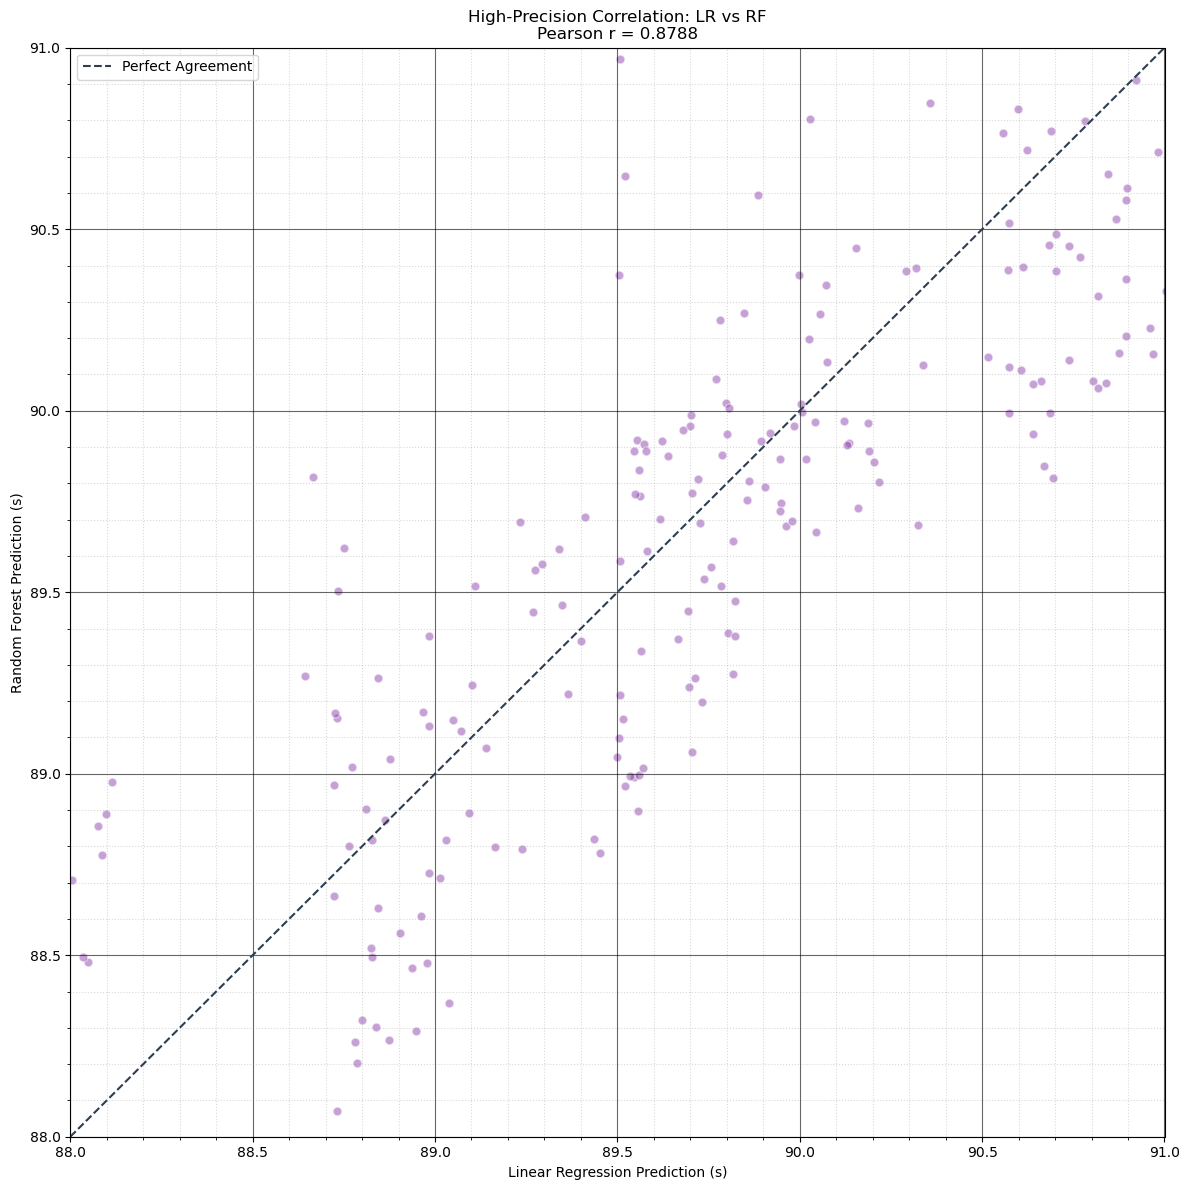

In [42]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np

lr_raw = lr_model_clean.predict(X_test_scaled)
rf_raw = rf_model.predict(X_test_scaled)

# Handle Multi-Output vs Single Output dynamically
# If the prediction has 2 dimensions (S1, S2, S3), we sum them. 
# Otherwise, we use the raw values.
lr_final = lr_raw.sum(axis=1) if lr_raw.ndim > 1 else lr_raw
rf_final = rf_raw.sum(axis=1) if rf_raw.ndim > 1 else rf_raw

fig, ax = plt.subplots(figsize=(12, 12))

# Zooming into the 88s - 91s
zoom_min, zoom_max = 88.0, 91.0 
ax.set_xlim(zoom_min, zoom_max)
ax.set_ylim(zoom_min, zoom_max)

# Set grid to every 0.1 seconds (100ms) for high accuracy
ax.xaxis.set_major_locator(MultipleLocator(0.5)) # Every 500ms
ax.xaxis.set_minor_locator(MultipleLocator(0.1)) # Every 100ms
ax.yaxis.set_major_locator(MultipleLocator(0.5))
ax.yaxis.set_minor_locator(MultipleLocator(0.1))

ax.scatter(lr_final, rf_final, alpha=0.5, color='#8e44ad', edgecolors='white', s=40)
ax.plot([zoom_min, zoom_max], [zoom_min, zoom_max], color='#2c3e50', linestyle='--', label='Perfect Agreement')

correlation = np.corrcoef(lr_final, rf_final)[0, 1]
ax.set_title(f'High-Precision Correlation: LR vs RF\nPearson r = {correlation:.4f}')
ax.set_xlabel('Linear Regression Prediction (s)')
ax.set_ylabel('Random Forest Prediction (s)')

# Enable the high-precision grid
ax.grid(which='minor', alpha=0.3, linestyle=':', color='gray')
ax.grid(which='major', alpha=0.6, linestyle='-', color='black')
ax.legend()

plt.tight_layout()
plt.show()

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math
import pandas as pd

# Calculate Linear Regression Metrics (Clean Data)
lr_mae = mean_absolute_error(y_test_total, lr_predictions_clean)
lr_rmse = math.sqrt(mean_squared_error(y_test_total, lr_predictions_clean))

# Calculate Random Forest Metrics (Clean Data)
rf_mae = mean_absolute_error(y_test_total, rf_predictions_total)
rf_rmse = math.sqrt(mean_squared_error(y_test_total, rf_predictions_total))

# Create the Comparison DataFrame
# We categorise by Model Type and Dataset Quality
metrics_data = [
    {
        "Model": "Linear Regression",
        "Type": "Baseline",
        "Dataset": "Clean (No Outliers)",
        "R² Score": lr_r2_clean,
        "RMSE (s)": lr_rmse,
        "MAE (s)": lr_mae,
        "Description": "Simple linear relationship"
    },
    {
        "Model": "Random Forest",
        "Type": "Advanced",
        "Dataset": "Clean (No Outliers)",
        "R² Score": rf_r2_total,
        "RMSE (s)": rf_rmse,
        "MAE (s)": rf_mae,
        "Description": "Captures non-linear physics"
    }
]

df_metrics = pd.DataFrame(metrics_data)

# formatting and Display
# Set the index to 'Model' for a cleaner look
df_display = df_metrics.set_index("Model")

# Round numeric columns for readability
df_display = df_display.round(4)

print("MODEL PERFORMANCE COMPARISON:")
try:
    display(df_display)
except:
    print(df_display)

MODEL PERFORMANCE COMPARISON:


,Type,Dataset,R² Score,RMSE (s),MAE (s),Description
Model,,,,,,
Linear Regression,Baseline,Clean (No Outliers),0.6989,0.6006,0.4623,Simple linear relationship
Random Forest,Advanced,Clean (No Outliers),0.7558,0.5408,0.3537,Captures non-linear physics
